In [1]:
somerset_bounds = {
    "west": -3.85,
    "south": 50.75,
    "east": -2.55,
    "north": 51.40
}

In [17]:
import mercantile
import requests
from pathlib import Path
import time

west, south, east, north = -3.85, 50.75, -2.55, 51.40

tile_folder = Path("tiles")

headers = {
    "User-Agent": "SomersetAnalytics/1.0"
}

for z in range(8, 15):

    tiles = mercantile.tiles(
        west,
        south,
        east,
        north,
        [z]
    )

    for tile in tiles:

        x = tile.x
        y = tile.y

        folder = tile_folder / str(z) / str(x)
        folder.mkdir(parents=True, exist_ok=True)

        outfile = folder / f"{y}.png"

        if outfile.exists():
            continue

        url = f"https://tile.openstreetmap.org/{z}/{x}/{y}.png"

        r = requests.get(url, headers=headers)

        if r.status_code == 200:
            outfile.write_bytes(r.content)

        print(f"{z}/{x}/{y} -> {r.status_code}")

        time.sleep(0.1)

8/125/85 -> 200
8/126/85 -> 200
9/250/170 -> 200
9/250/171 -> 200
9/251/170 -> 200
9/251/171 -> 200
9/252/170 -> 200
9/252/171 -> 200
10/501/340 -> 200
10/501/341 -> 200
10/501/342 -> 200
10/501/343 -> 200
10/502/340 -> 200
10/502/341 -> 200
10/502/342 -> 200
10/502/343 -> 200
10/503/340 -> 200
10/503/341 -> 200
10/503/342 -> 200
10/503/343 -> 200
10/504/340 -> 200
10/504/341 -> 200
10/504/342 -> 200
10/504/343 -> 200
11/1002/681 -> 200
11/1002/682 -> 200
11/1002/683 -> 200
11/1002/684 -> 200
11/1002/685 -> 200
11/1002/686 -> 200
11/1002/687 -> 200
11/1003/681 -> 200
11/1003/682 -> 200
11/1003/683 -> 200
11/1003/684 -> 200
11/1003/685 -> 200
11/1003/686 -> 200
11/1003/687 -> 200
11/1004/681 -> 200
11/1004/682 -> 200
11/1004/683 -> 200
11/1004/684 -> 200
11/1004/685 -> 200
11/1004/686 -> 200
11/1004/687 -> 200
11/1005/681 -> 200
11/1005/682 -> 200
11/1005/683 -> 200
11/1005/684 -> 200
11/1005/685 -> 200
11/1005/686 -> 200
11/1005/687 -> 200
11/1006/681 -> 200
11/1006/682 -> 200
11/1006/

KeyboardInterrupt: 

(256, 256)


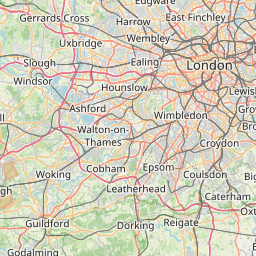

In [16]:
from PIL import Image

img = Image.open("test_tile.png")

print(img.size)
img

In [11]:
import folium

m = folium.Map(
    location=[51.0, -3.1],
    zoom_start=9,
    tiles=None
)

folium.TileLayer(
    tiles='http://127.0.0.1:5000/tiles/{z}/{x}/{y}.png',
    attr='Somerset Tiles',
    overlay=False,
    control=False
).add_to(m)

m.save("somerset_map.html")

In [7]:
import requests

url = "https://tile.openstreetmap.org/9/255/170.png"

r = requests.get(url)

with open("test.png", "wb") as f:
    f.write(r.content)

In [2]:
import mercantile
import requests
from pathlib import Path

tile_dir = Path("tiles")

for z in range(8, 15):  # zoom levels
    tiles = mercantile.tiles(
        somerset_bounds["west"],
        somerset_bounds["south"],
        somerset_bounds["east"],
        somerset_bounds["north"],
        [z]
    )

    for tile in tiles:
        x, y = tile.x, tile.y

        url = f"https://tile.openstreetmap.org/{z}/{x}/{y}.png"

        folder = tile_dir / str(z) / str(x)
        folder.mkdir(parents=True, exist_ok=True)

        outfile = folder / f"{y}.png"

        if not outfile.exists():
            r = requests.get(url)
            outfile.write_bytes(r.content)

In [4]:

import folium 
m = folium.Map(
    location=[51.0, -3.1],
    zoom_start=9,
    tiles=None
)

folium.TileLayer(
    tiles='https://jupyterhub.somersetft.nhs.uk/user/jawad.iqbal/lab/tree/DataScience/jupyter-jawad.iqbal/map_tiles/tiles/{z}/{x}/{y}.png',
    attr='OpenStreetMap',
    overlay=False,
    control=False
).add_to(m)

In [20]:
import geopandas as gpd
somerset_boundary = gpd.read_file("../somerset_geojson_files/somerset_boundary.geojson")

In [22]:
import folium

m = folium.Map(
    location=[51.0, -3.1],
    zoom_start=9,
    min_zoom=8,
    max_zoom=14,
    tiles=None
)

folium.TileLayer(
    tiles='/user/jawad.iqbal/files/DataScience/jupyter-jawad.iqbal/map_tiles/tiles/{z}/{x}/{y}.png',
    attr='Local Tiles',
    min_zoom=8,
    max_zoom=14,
    max_native_zoom=14,
    min_native_zoom=8
).add_to(m)

folium.GeoJson(
    somerset_boundary.boundary,
    style_function=lambda x: {"color": "brown", "weight": 3},
    name="Somerset Boundary",
).add_to(m)

m.save("mymap.html")